# Finding pilot patient

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import extract_ews_transfer, extract_ews_window, extract_tws_transfer, extract_tws_window, extract_ews_static, extract_tws_static

In [13]:
def extract_ews_transfer_08_06(performances, patient_nr: int, last_online_session: int):
    print(f"Extracting from performances with the following keys: \n{performances.keys()}")
    #ews_transfer_lda = np.zeros(last_online_session-2)
    ews_transfer_slda = np.zeros(last_online_session-2)
    ews_transfer_btlda = np.zeros(last_online_session-2)

    session = 3 # first online session
    p = patient_nr
    extra = 0

    if p == 8:
        session = 4
        extra +=1
    
    for i in range(last_online_session-2-extra):
        #ews_transfer_lda[i] = performances.get(f'p{p}_transfer_fixed_s{session}').get('epoch-wise').get('lda')
        ews_transfer_slda[i] = performances.get(f'p{p}_transfer_s{session}').get('epoch-wise').get('slda')
        ews_transfer_btlda[i] = performances.get(f'p{p}_transfer_s{session}').get('epoch-wise').get('btlda')
        session+=1
    return (#ews_transfer_lda, 
        ews_transfer_slda, 
        ews_transfer_btlda)  

def extract_tws_transfer_08_06(performances, patient_nr: int, last_online_session: int):
    print(f"Extracting from performances with the following keys: \n{performances.keys()}")
    #ews_transfer_lda = np.zeros(last_online_session-2)
    tws_transfer_slda = np.zeros(last_online_session-2)
    tws_transfer_btlda = np.zeros(last_online_session-2)

    session = 3 # first online session
    p = patient_nr

    if p==8:
        session = 4

    # if p==8: session = 4 (for patient 8)
    
    for i in range(last_online_session-2):
        #ews_transfer_lda[i] = performances.get(f'p{p}_transfer_fixed_s{session}').get('epoch-wise').get('lda')
        tws_transfer_slda[i] = performances.get(f'p{p}_transfer_s{session}').get('trial-wise').get('slda')
        tws_transfer_btlda[i] = performances.get(f'p{p}_transfer_s{session}').get('trial-wise').get('btlda')
        session+=1
    return (#ews_transfer_lda, 
        tws_transfer_slda, 
        tws_transfer_btlda)  


In [14]:
from db import patients_db

# all_performances_original=dict()
all_performances_new = dict()

print(patients_db)
for id in patients_db:

    info = patients_db.get(id)
    patient = info.get('patient_nr')
    last_session = info.get('last_session')
    calibration_selection = info.get('selection')

    print("patient: ", patient)
    print("last session", last_session)
    print("calibration_selection", calibration_selection)

    # with open(f'p{patient}_performances_08_06.pkl', 'rb') as f:
    #     performances_original = pickle.load(f) 

    with open(f'p{patient}_performances_v1.pkl', 'rb') as f:
        performances_new = pickle.load(f)    

    # all_performances_original.update({f"p{patient}": performances_original})
    all_performances_new.update({f"p{patient}": performances_new})

# print(all_performances_original.keys())
print(all_performances_new.keys())


{1: {'patient_nr': 1, 'last_session': 18, 'selection': '6D_long_350'}, 2: {'patient_nr': 2, 'last_session': 14, 'selection': '6D_long_350'}, 3: {'patient_nr': 3, 'last_session': 17, 'selection': '6D_short_250'}, 4: {'patient_nr': 4, 'last_session': 20, 'selection': '6D_long_350'}, 5: {'patient_nr': 5, 'last_session': 14, 'selection': '6D_short_250'}, 6: {'patient_nr': 6, 'last_session': 16, 'selection': '6D_short_250'}, 7: {'patient_nr': 7, 'last_session': 28, 'selection': '6D_long_350'}, 8: {'patient_nr': 8, 'last_session': 19, 'selection': '6D_short_250'}, 9: {'patient_nr': 9, 'last_session': 18, 'selection': '6D_long_350'}, 10: {'patient_nr': 10, 'last_session': 16, 'selection': '6D_long_350'}}
patient:  1
last session 18
calibration_selection 6D_long_350
patient:  2
last session 14
calibration_selection 6D_long_350
patient:  3
last session 17
calibration_selection 6D_short_250
patient:  4
last session 20
calibration_selection 6D_long_350
patient:  5
last session 14
calibration_sele

In [16]:
# all_performances_original=dict()
ews_all_patients = dict()

for id in patients_db:

    info = patients_db.get(id)
    patient = info.get('patient_nr')
    last_session = info.get('last_session')
    calibration_selection = info.get('selection')

    print("patient: ", patient)
    print("last session", last_session)
    print("calibration_selection", calibration_selection)

    # with open(f'p{patient}_performances_08_06.pkl', 'rb') as f:
    #     performances_original = pickle.load(f) 

    with open(f'p{patient}_performances_v1.pkl', 'rb') as f:
        performances_new = pickle.load(f)    

        
    ews_transfer_slda_08_06, ews_transfer_btlda_08_06 = extract_ews_transfer_08_06(performances_new, patient, last_session-1)
    #tws_transfer_slda_08_06, tws_transfer_btlda_08_06 = extract_tws_transfer_08_06(performances_new, patient, last_session-1)

    # all_performances_original.update({f"p{patient}": performances_original})
    ews_all_patients.update({f"p{patient}": (ews_transfer_slda_08_06, ews_transfer_btlda_08_06)})
    #all_performances_new.update({f"p{patient}": performances_new})

# print(all_performances_original.keys())
#print(all_performances_new.keys())



# ews_transfer_slda_08_06, ews_transfer_btlda_08_06 = extract_ews_transfer_08_06(p1_performances_original, 1, 17)
# tws_transfer_slda_08_06, tws_transfer_btlda_08_06 = extract_tws_transfer_08_06(p1_performances_original, 1, 17)

# ews_transfer_slda_new, ews_transfer_btlda_new = extract_ews_transfer_08_06(p1_performances_v1, 1, 18)
# tws_transfer_slda_new, tws_transfer_btlda_new = extract_tws_transfer_08_06(p1_performances_v1, 1, 18)


patient:  1
last session 18
calibration_selection 6D_long_350
Extracting from performances with the following keys: 
dict_keys(['p1_transfer_s3', 'p1_transfer_s4', 'p1_transfer_s5', 'p1_transfer_s6', 'p1_transfer_s7', 'p1_transfer_s8', 'p1_transfer_s9', 'p1_transfer_s10', 'p1_transfer_s11', 'p1_transfer_s12', 'p1_transfer_s13', 'p1_transfer_s14', 'p1_transfer_s15', 'p1_transfer_s16', 'p1_transfer_s17'])
patient:  2
last session 14
calibration_selection 6D_long_350
Extracting from performances with the following keys: 
dict_keys(['p2_transfer_s3', 'p2_transfer_s4', 'p2_transfer_s5', 'p2_transfer_s6', 'p2_transfer_s7', 'p2_transfer_s8', 'p2_transfer_s9', 'p2_transfer_s10', 'p2_transfer_s11', 'p2_transfer_s12', 'p2_transfer_s13'])
patient:  3
last session 17
calibration_selection 6D_short_250
Extracting from performances with the following keys: 
dict_keys(['p3_transfer_s3', 'p3_transfer_s4', 'p3_transfer_s5', 'p3_transfer_s6', 'p3_transfer_s7', 'p3_transfer_s8', 'p3_transfer_s9', 'p3_tra

In [22]:
print(ews_all_patients.get('p1')[0])

[0.58512851 0.67857181 0.70415939 0.72186223 0.79821625 0.79723387
 0.80215574 0.86061124 0.86490822 0.86813733 0.88900019 0.90192898
 0.896366   0.88515811 0.90630158]


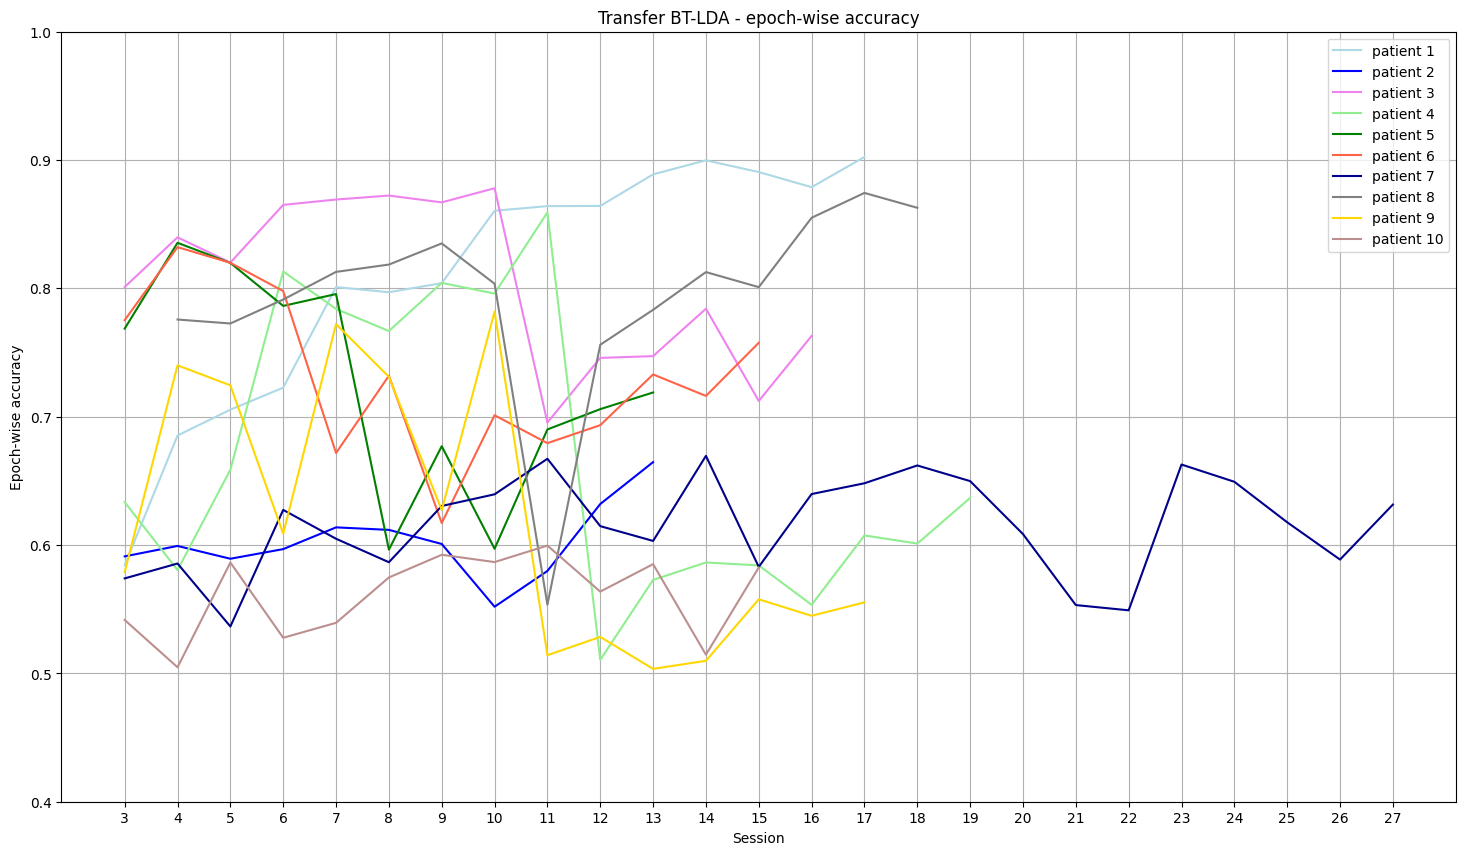

In [79]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# Choose a colormap (e.g., viridis, plasma, inferno, cool, etc.)
#cmap = cm.get_cmap('cool', 10)  # You can change 'plasma' to another cmap
colors=['lightblue','lightblue','blue','violet','lightgreen','green','tomato', 'darkblue', 'grey', 'gold', 'rosybrown']

plt.figure(figsize=(18,10))
for i in range (1,11):
    color = colors[i]
    y = ews_all_patients.get(f'p{i}')[1]
    if i!=8:
        plt.plot(np.arange(0,len(y)), y, label=f"patient {i}", color=color)
    else:
        plt.plot(np.arange(1,len(y)), y[:-1], label=f"patient {i}", color=color)
plt.ylabel('Epoch-wise accuracy')
plt.xlabel('Session')
plt.ylim(0.4,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title('Transfer BT-LDA - epoch-wise accuracy')   
plt.grid() 
plt.show()